# Figure 3F — do knockouts that interact physically also correlate?

Takes the STRING protein interactions among the screened E3 ligases, asks
whether interacting pairs have correlated knockout effect profiles, and tests
the result against degree-preserving rewiring of the interaction network.

## Setup

In [1]:
library(ggplot2)
library(pheatmap)
library(data.table)
library(reshape2)      # after data.table, so melt() is reshape2's
library(igraph)
library(ggpubr)
library(BiRewire)      # degree-preserving network rewiring

# NOTE: Main.R is deliberately not sourced. It loads ICtest, whose Ops method
# conflicts with the S7 objects in ggplot2 4.x and makes every `+` chain fail
# with 'Incompatible methods ("Ops.S7_object", "+.gg")', silently producing
# empty PDFs.

`%ni%` <- Negate(`%in%`)

# Hmisc is not installed here. For complete data this is exactly what
# Hmisc::rcorr(type = "pearson") computes.
rcorr <- function(m, type = "pearson") {
    r <- cor(m, method = type)
    n <- nrow(m)
    tstat <- r * sqrt((n - 2) / (1 - r^2))
    p <- 2 * pt(-abs(tstat), df = n - 2)
    diag(p) <- 0
    list(r = r, P = p)
}

save_pheatmap_pdf <- function(x, filename, width = 7, height = 7) {
    stopifnot(!missing(x), !missing(filename))
    pdf(filename, width = width, height = height)
    grid::grid.newpage(); grid::grid.draw(x$gtable); dev.off()
}

dir.create("figures", showWarnings = FALSE)
dir.create("outputs", showWarnings = FALSE)


Attaching package: ‘reshape2’


The following objects are masked from ‘package:data.table’:

    dcast, melt



Attaching package: ‘igraph’


The following objects are masked from ‘package:stats’:

    decompose, spectrum


The following object is masked from ‘package:base’:

    union


Loading required package: slam


Attaching package: ‘slam’


The following object is masked from ‘package:data.table’:

    rollup


Loading required package: Rtsne

Loading required package: Matrix



In [2]:
E3LIGASE <- "/home/eraslab1/Projects/E3Ligase/analysisSingle"

E3_METADATA   <- file.path(E3LIGASE, "ManuscriptFigures/TextFiles/220610_regulators_metadata_E3_Complex.csv")
GUIDE_MODULES <- file.path(E3LIGASE, "TextFiles/ME_GuideModules_leiden_6_Modules.csv")
GENE_MODULES  <- file.path(E3LIGASE, "TextFiles/ME_GeneModules_leiden_11_Modules.csv")
STRING_ALIAS  <- file.path(E3LIGASE, "TextFiles/PositiveControls/10090.protein.aliases.v11.5.txt")
STRING_LINKS  <- file.path(E3LIGASE, "TextFiles/PositiveControls/10090.protein.links.detailed.txt")
LINKS_OURGENES<- file.path(E3LIGASE, "TextFiles/10090.protein.links.detailed_ourGenes.txt")
BETA_SIGNIF   <- file.path(E3LIGASE, "EffectSizes/MixedEffectLMOutputs/ME_SignificantBetaCoefs.csv")
PUBLISHED_E3_GRAPH <- file.path(E3LIGASE, "ManuscriptFigures/TextFiles/Only_E3s.csv")
SIMULATED_FREQ     <- file.path(E3LIGASE, "ManuscriptFigures/RDSFiles/allSimulatedFreq.rds")

CORRELATION_ALPHA <- 0.05    # correlations less significant than this are set to zero
N_REWIRINGS       <- 100     # rewired networks drawn for the observed/sampled comparison
RANDOM_SEED       <- 6

# Modules are displayed as M1..M6, but the stored simulation (allSimulatedFreq.rds)
# and its matrix are keyed by the older K numbering, so joins against it use the K form.
K_OF_MODULE <- c(M2 = "K0", M3 = "K1", M6 = "K2", M5 = "K3", M1 = "K4", M4 = "K5")
MODULE_OF_K <- setNames(names(K_OF_MODULE), K_OF_MODULE)

annoCols <- list(
    GeneGroup = c(GeneGroup_0 = "#1B9E77", GeneGroup_1 = "#D95F02", GeneGroup_2 = "#7570B3",
                  GeneGroup_3 = "#E7298A", GeneGroup_4 = "#66A61E", GeneGroup_5 = "#E6AB02",
                  GeneGroup_6 = "#A6761D", GeneGroup_7 = "#666666"),
    GuideGroup = c(M1 = "#aa40fc", M2 = "#1f77b4", M3 = "#ff7f0e",
                   M4 = "#8c564b", M5 = "#d62728", M6 = "#279e68")
)

## E3 ligases, guide modules, and the STRING interactions among them

In [3]:
realE3s <- as.data.frame(read.csv(E3_METADATA), stringsAsFactors = FALSE)
e3s <- unique(realE3s$Symbol_guides)
e3s <- e3s[e3s != '']

koModules <- read.csv(GUIDE_MODULES, row.names = 1)
koModules$GuideGroup <- koModules$NewGuideGroup    # modules are named M1..M6
koModules$NewGuideGroup <- NULL
geneModules <- read.csv(GENE_MODULES, row.names = 1)
allConsideredGenes <- unique(c(koModules$GuideName, geneModules$GeneName))

cat("E3 ligases:", length(e3s), " genes considered:", length(allConsideredGenes), "\n")

E3 ligases: 165  genes considered: 1346 


In [4]:
proInf <- read.csv(STRING_ALIAS, sep = "\t")
proInf <- unique(proInf[proInf$alias %in% allConsideredGenes, c("X.string_protein_id", "alias")])
colnames(proInf) <- c("ProID", "GeneName")

allInteractions <- read.csv(STRING_LINKS, sep = " ")
allInteractions <- allInteractions[allInteractions$protein1 %in% proInf$ProID, ]
allInteractions <- allInteractions[allInteractions$protein2 %in% proInf$ProID, ]
write.csv(allInteractions, "outputs/10090.protein.links.detailed_ourGenes.txt", row.names = FALSE)

# read back the stored copy, so the analysis matches the published one
allInteractions <- read.csv(LINKS_OURGENES)

# attach the gene name behind each protein id, on both sides of the pair
for (side in c(1, 2)) {
    lookup <- copy(proInf)
    colnames(lookup) <- c("ProID", paste0("GeneName_", side))
    allInteractions$ProID <- allInteractions[[paste0("protein", side)]]
    allInteractions <- merge(allInteractions, lookup, by = "ProID")
}
allInteractions$ProID <- NULL
allInteractions$GenePair <- apply(allInteractions, 1, function(x) {
    paste0(sort(c(x["GeneName_1"], x["GeneName_2"])), collapse = "_")
})
dim(allInteractions)

[1] 255848     13

In [5]:
allInteractions_KOs <- allInteractions[allInteractions$GeneName_1 %in% koModules$GuideName &
                                       allInteractions$GeneName_2 %in% koModules$GuideName, ]
allInteractions_E3s <- allInteractions[allInteractions$GeneName_1 %in% e3s &
                                       allInteractions$GeneName_2 %in% e3s, ]
cat("interactions among knockouts:", nrow(allInteractions_KOs),
    " among E3 ligases:", nrow(allInteractions_E3s), "\n")

interactions among knockouts: 25268  among E3 ligases: 7790 


## Correlation between knockout effect profiles

Correlations that are not significant are set to zero, so only supported
relationships enter the network.

In [6]:
coefsAll <- read.csv(BETA_SIGNIF, row.names = 1)
rownames(coefsAll) <- sapply(rownames(coefsAll), function(x) strsplit(x, "_")[[1]][2])

myCorr <- rcorr(t(coefsAll), type = "pearson")
myCovar <- data.frame(myCorr$r)
myCovar[data.frame(myCorr$P) > CORRELATION_ALPHA] <- 0
dim(myCovar)

[1] 329 329

## The interaction graph, annotated with correlation and module

In [7]:
getInteractionGraph <- function(IntGraph, myCovar, koModules) {
    for (i in 1:nrow(IntGraph)) {
        IntGraph[i, "CorValue"] <- myCovar[IntGraph[i, "GeneName_1"], IntGraph[i, "GeneName_2"]]
    }
    koModulesSelected <- koModules[koModules$GuideName %in%
                                   unique(c(IntGraph$GeneName_1, IntGraph$GeneName_2)), ]
    for (side in c(1, 2)) {
        km <- copy(koModulesSelected)
        colnames(km) <- c("GuideName", paste0("GuideGroup_gene", side), paste0("GuideColor_gene", side))
        IntGraph$GuideName <- IntGraph[[paste0("GeneName_", side)]]
        IntGraph <- merge(IntGraph, km, by = "GuideName")
    }
    graph <- graph_from_data_frame(IntGraph[, c("GeneName_1", "GeneName_2")],
                                   vertices = koModulesSelected, directed = FALSE)
    list(myGr = graph, IntGraph = IntGraph)
}

In [8]:
res2 <- getInteractionGraph(allInteractions_E3s, myCovar, koModules)$IntGraph
res2$GuideName <- NULL
res2 <- res2[res2$GeneName_1 != res2$GeneName_2, ]
write.csv(res2, "outputs/Only_E3s.csv", row.names = FALSE)

# the published graph is used from here on, so the figure reproduces the paper
res2 <- read.csv(PUBLISHED_E3_GRAPH)

# reduce each correlation to its sign; zero means no significant correlation
res2$CorValueBinary <- sign(res2$CorValue)
res2$CorValueBinary[res2$CorValueBinary == 0] <- NA
nrow(res2)

[1] 2512

## Adjacency matrix of E3-E3 interactions

In [9]:
uE3s <- sort(unique(c(res2$GeneName_1, res2$GeneName_2)))
myDF <- data.frame(matrix(0, nrow = length(uE3s), ncol = length(uE3s)))
colnames(myDF) <- rownames(myDF) <- uE3s
for (i in 1:nrow(res2)) {
    myDF[res2[i, "GeneName_1"], res2[i, "GeneName_2"]] <- res2[i, "CorValueBinary"]
    myDF[res2[i, "GeneName_2"], res2[i, "GeneName_1"]] <- res2[i, "CorValueBinary"]
}

koModulesE3s <- koModules[koModules$GuideName %in% uE3s, ]
koModulesE3s$GuideGroup <- factor(koModulesE3s$GuideGroup, levels = unique(koModulesE3s$GuideGroup))
myDF <- myDF[koModulesE3s$GuideName, koModulesE3s$GuideName]

moduleAnnotation <- function(names) {
    a <- koModulesE3s[names, ]
    a$GuideName <- NULL; a$GuideColor <- NULL
    a
}
dim(myDF)

[1] 164 164

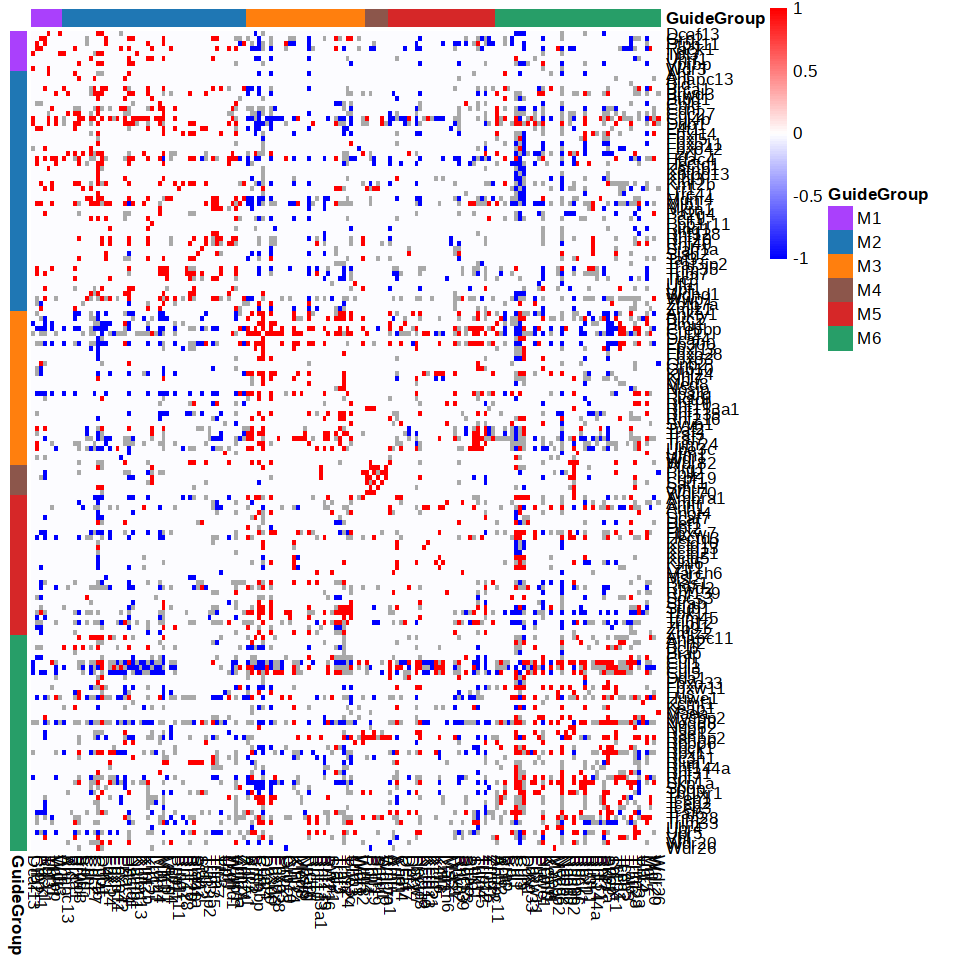

In [10]:
options(repr.plot.width = 8, repr.plot.height = 8)
pheatmap(myDF,
         annotation_col = moduleAnnotation(rownames(myDF)),
         annotation_row = moduleAnnotation(rownames(myDF)),
         annotation_colors = annoCols,
         cluster_rows = FALSE, cluster_cols = FALSE,
         clustering_method = "ward.D2", treeheight_row = 0, treeheight_col = 0,
         colorRampPalette(c("blue", "white", "red"))(100), na_col = "darkgrey")

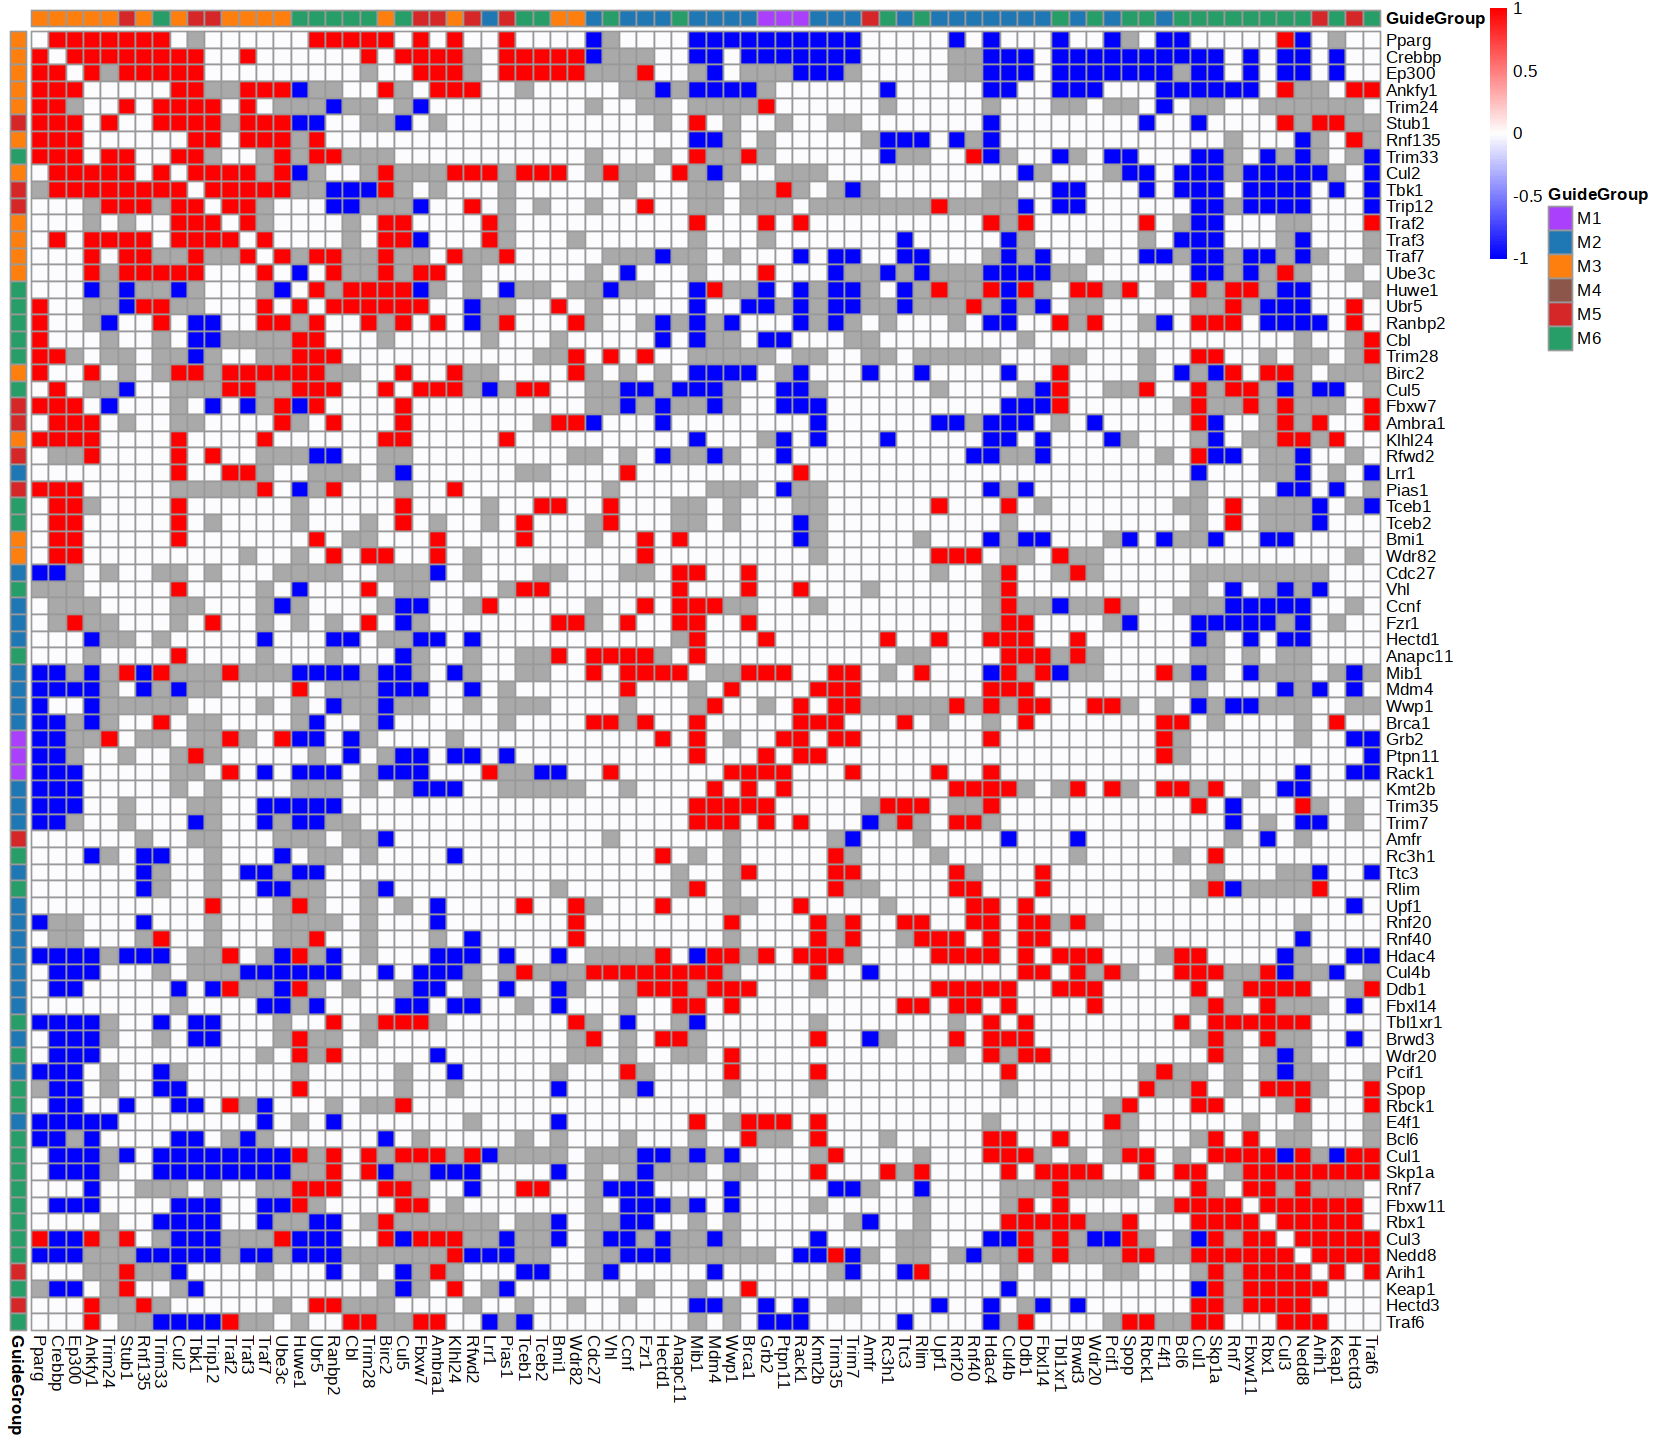

In [11]:
# genes with at least a few interactions, clustered rather than module-ordered
zeroCounts <- sapply(myDF, function(x) length(x[which(x == 0)]))
selGenes <- names(zeroCounts[zeroCounts < 141])
myDF_selected <- myDF[selGenes, selGenes]

options(repr.plot.width = 14, repr.plot.height = 12)
pheatmap(myDF_selected,
         annotation_col = moduleAnnotation(rownames(myDF_selected)),
         annotation_row = moduleAnnotation(rownames(myDF_selected)),
         annotation_colors = annoCols,
         clustering_method = "ward.D2", treeheight_row = 0, treeheight_col = 0,
         clustering_distance_rows = "euclidean",
         colorRampPalette(c("blue", "white", "red"))(100), na_col = "darkgrey")

## Are within-module interactions more frequent than chance?

Interaction counts per module pair are compared against a stored set of 200
degree-preserving rewirings of the same network. The generator for that file
is `birewire.rewire.undirected` applied 200 times; the result is read here
rather than recomputed.

In [12]:
adjOrj <- copy(myDF)
# key by the K form so the pairs join against allSimulatedFreq.rds
rownames(adjOrj) <- paste0(rownames(adjOrj), "_", K_OF_MODULE[as.character(koModulesE3s[rownames(adjOrj), "GuideGroup"])])
colnames(adjOrj) <- paste0(colnames(adjOrj), "_", K_OF_MODULE[as.character(koModulesE3s[colnames(adjOrj), "GuideGroup"])])
adjOrj[adjOrj != 0 | is.na(adjOrj)] <- 1

modulePairFrequencies <- function(adjacency) {
    m <- copy(adjacency)
    m$Gene <- rownames(m)
    m <- melt(m, id.vars = "Gene")
    m$Group1 <- sapply(m$Gene, function(x) strsplit(as.character(x), "_")[[1]][2])
    m$Group2 <- sapply(m$variable, function(x) strsplit(as.character(x), "_")[[1]][2])
    m$GroupPair <- apply(m, 1, function(x) paste0(sort(c(x["Group1"], x["Group2"])), collapse = "_"))
    data.frame(table(m[m$value == 1, "GroupPair"]))
}

observedInterFreq <- modulePairFrequencies(adjOrj)
observedInterFreq$G1 <- sapply(observedInterFreq$Var1, function(x) strsplit(as.character(x), "_")[[1]][1])
observedInterFreq$G2 <- sapply(observedInterFreq$Var1, function(x) strsplit(as.character(x), "_")[[1]][2])
head(observedInterFreq)

,Var1,Freq,G1,G2
,<fct>,<int>,<chr>,<chr>
1,K0_K0,367,K0,K0
2,K0_K1,494,K0,K1
3,K0_K2,882,K0,K2
4,K0_K3,348,K0,K3
5,K0_K4,86,K0,K4
6,K0_K5,40,K0,K5


In [13]:
allSimulatedFreq <- readRDS(SIMULATED_FREQ)

allGroups <- c("K0", "K1", "K2", "K3", "K4", "K5")
allSgnMatrix <- data.frame(matrix(NA, 6, 6), row.names = allGroups)
colnames(allSgnMatrix) <- allGroups

for (i in 1:nrow(observedInterFreq)) {
    observed <- observedInterFreq[i, "Freq"]
    simulated <- allSimulatedFreq[as.character(allSimulatedFreq$Var1) ==
                                  as.character(observedInterFreq[i, "Var1"]), "Freq"]
    allSgnMatrix[observedInterFreq[i, "G1"], observedInterFreq[i, "G2"]] <-
        length(simulated[simulated > observed]) / length(simulated)
}

# displayed with the module names
rownames(allSgnMatrix) <- MODULE_OF_K[rownames(allSgnMatrix)]
colnames(allSgnMatrix) <- MODULE_OF_K[colnames(allSgnMatrix)]
allSgnMatrix

,M2,M3,M6,M5,M1,M4
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
M2,0.005,0.850,0.520,0.830,0.640,0.6550000
M3,NA,0.625,0.740,0.000,0.115,1.0000000
M6,NA,NA,0.005,0.850,0.995,0.8850000
M5,NA,NA,NA,0.665,0.190,0.9450000
M1,NA,NA,NA,NA,0.000,0.2756757
M4,NA,NA,NA,NA,NA,0.0000000


## Observed correlations against rewired networks

:::{warning}
The original notebook computed the rewired counts and then, by what looks like
a copy-paste slip, stored the *observed* counts in the `sampled...` columns, so
the comparison below was observed against itself. The sampled values are used
here. Revert to `numberOfPositiveInteractions` / `numberOfNegativeInteractions`
in the loop to reproduce the original panel.
:::

In [14]:
nGenes <- nrow(myDF)
observedInteractionCor <- data.frame(
    numberOfInteractions               = sapply(myDF, function(x) nGenes - length(x[which(x == 0)])),
    ObservedPositiveInteractions       = sapply(myDF, function(x) length(x[which(x > 0)])),
    ObservedNegativeInteractions       = sapply(myDF, function(x) length(x[which(x < 0)])),
    numberOfUncorrelationgInteractions = sapply(myDF, function(x) length(x[which(is.na(x))]))
)
head(observedInteractionCor)

,numberOfInteractions,ObservedPositiveInteractions,ObservedNegativeInteractions,numberOfUncorrelationgInteractions
,<int>,<int>,<int>,<int>
Dcaf13,13,4,5,4
Grb2,37,11,9,17
Ptpn11,32,8,15,9
Rack1,42,13,21,8
Tbl3,9,6,0,3
Uhrf1,16,7,5,4


In [15]:
myCovarTmp <- sign(myCovar[rownames(myDF), colnames(myDF)])

allSampledInter <- data.frame()
for (i in 1:N_REWIRINGS) {
    adjCor <- copy(myDF)
    adjCor[adjCor != 0 | is.na(adjCor)] <- 1
    rewired <- birewire.rewire.undirected(adjCor)
    rewired[rewired == 0] <- NA
    sampledInter <- myCovarTmp * rewired

    allSampledInter <- rbind(allSampledInter, data.frame(
        numberOfInteractions               = sapply(sampledInter, function(x) nGenes - length(x[which(is.na(x))])),
        sampledPositiveInteractions        = sapply(sampledInter, function(x) length(x[which(x > 0)])),
        sampledNegativeInteractions        = sapply(sampledInter, function(x) length(x[which(x < 0)])),
        numberOfUncorrelationgInteractions = sapply(sampledInter, function(x) length(x[which(x == 0)]))
    ))
}
dim(allSampledInter)

DONE in 0 seconds 
DONE in 0 seconds 
DONE in 0 seconds 
DONE in 0 seconds 
DONE in 0 seconds 
DONE in 0 seconds 
DONE in 0 seconds 
DONE in 0 seconds 
DONE in 0 seconds 
DONE in 0 seconds 
DONE in 0 seconds 
DONE in 0 seconds 
DONE in 0 seconds 
DONE in 0 seconds 
DONE in 0 seconds 
DONE in 0 seconds 
DONE in 0 seconds 
DONE in 0 seconds 
DONE in 0 seconds 
DONE in 0 seconds 
DONE in 0 seconds 
DONE in 0 seconds 
DONE in 0 seconds 
DONE in 0 seconds 
DONE in 0 seconds 
DONE in 0 seconds 
DONE in 0 seconds 
DONE in 0 seconds 
DONE in 0 seconds 
DONE in 0 seconds 
DONE in 0 seconds 
DONE in 0 seconds 
DONE in 0 seconds 
DONE in 0 seconds 
DONE in 0 seconds 
DONE in 0 seconds 
DONE in 0 seconds 
DONE in 0 seconds 
DONE in 0 seconds 
DONE in 0 seconds 
DONE in 0 seconds 
DONE in 0 seconds 
DONE in 0 seconds 
DONE in 0 seconds 
DONE in 0 seconds 
DONE in 0 seconds 
DONE in 0 seconds 
DONE in 0 seconds 
DONE in 0 seconds 
DONE in 0 seconds 
DONE in 0 seconds 
DONE in 0 seconds 
DONE in 0 se

[1] 16400     4

No id variables; using all as measure variables

No id variables; using all as measure variables



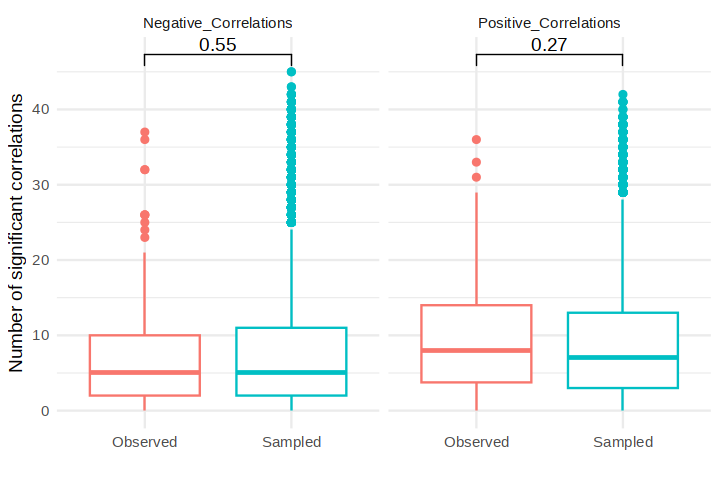

In [16]:
labelDirection <- function(df, positive, negative, type) {
    m <- melt(df[, c(positive, negative)])
    m$Direction <- ifelse(m$variable == negative, "Negative_Correlations", "Positive_Correlations")
    m$type <- type
    m
}
allInter <- rbind(
    labelDirection(allSampledInter, "sampledPositiveInteractions", "sampledNegativeInteractions", "Sampled"),
    labelDirection(observedInteractionCor, "ObservedPositiveInteractions", "ObservedNegativeInteractions", "Observed")
)

options(repr.plot.width = 6, repr.plot.height = 4)
ggplot(allInter, aes(x = type, y = value, color = type)) +
    geom_boxplot() + facet_wrap(~Direction) +
    labs(y = "Number of significant correlations") + theme_minimal() +
    stat_compare_means(method = "wilcox.test", comparisons = list(c("Observed", "Sampled"))) +
    theme(legend.position = "None") + xlab("")

## Paired comparison per gene

For each gene, its observed number of correlating partners against the same
number of randomly drawn partners.

In [17]:
myCovarE3s <- myCovar[rownames(myDF), colnames(myDF)]
myCovarE3s$genes <- rownames(myCovarE3s)
myCovarE3s <- melt(myCovarE3s)
myCovarE3s <- myCovarE3s[myCovarE3s$genes != myCovarE3s$variable, ]

set.seed(RANDOM_SEED)
for (gene in rownames(observedInteractionCor)) {
    partners <- myCovarE3s[myCovarE3s$variable == gene, ]
    drawn <- partners[sample(nrow(partners), observedInteractionCor[gene, "numberOfInteractions"]), "value"]
    observedInteractionCor[gene, "SampledPositiveInteractions"] <- length(which(drawn > 0))
    observedInteractionCor[gene, "SampledNegativeInteractions"] <- length(which(drawn < 0))
    observedInteractionCor[gene, "SampledNotSignInter"]        <- length(which(drawn == 0))
}
observedInteractionCor$ObservedCorrelatingInteractions <-
    observedInteractionCor$ObservedPositiveInteractions + observedInteractionCor$ObservedNegativeInteractions
observedInteractionCor$SampledCorrelatingInteractions <-
    observedInteractionCor$SampledPositiveInteractions + observedInteractionCor$SampledNegativeInteractions
observedInteractionCor$gene <- rownames(observedInteractionCor)
head(observedInteractionCor)

Using genes as id variables



,numberOfInteractions,ObservedPositiveInteractions,ObservedNegativeInteractions,numberOfUncorrelationgInteractions,SampledPositiveInteractions,SampledNegativeInteractions,SampledNotSignInter,ObservedCorrelatingInteractions,SampledCorrelatingInteractions,gene
,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<chr>
Dcaf13,13,4,5,4,5,6,2,9,11,Dcaf13
Grb2,37,11,9,17,15,8,14,20,23,Grb2
Ptpn11,32,8,15,9,10,10,12,23,20,Ptpn11
Rack1,42,13,21,8,15,18,9,34,33,Rack1
Tbl3,9,6,0,3,4,3,2,6,7,Tbl3
Uhrf1,16,7,5,4,10,5,1,12,15,Uhrf1


Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.
ℹ The deprecated feature was likely used in the ggpubr package.
  Please report the issue at <https://github.com/kassambara/ggpubr/issues>.”


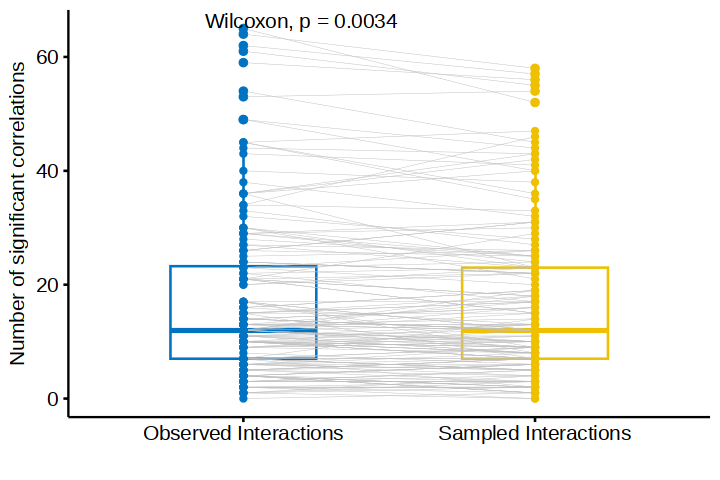

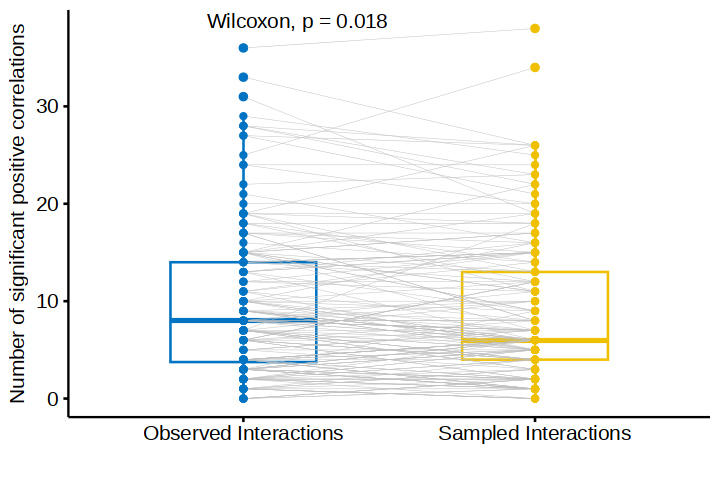

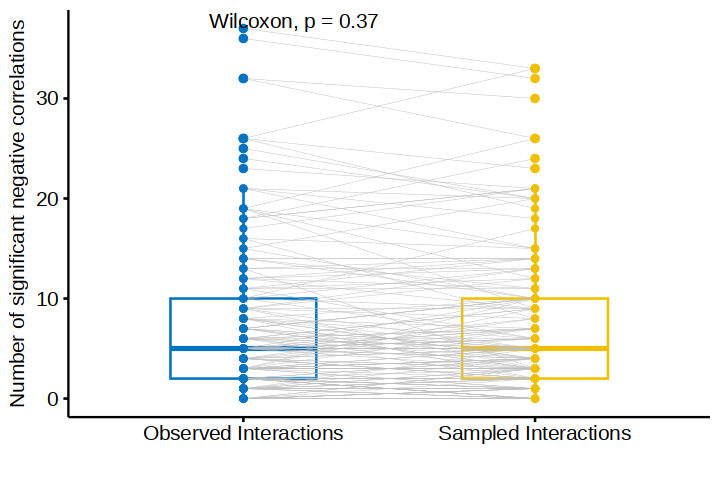

In [18]:
pairedPanel <- function(observedColumn, sampledColumn, yLabel) {
    df <- observedInteractionCor[, c("gene", observedColumn, sampledColumn)]
    colnames(df) <- c("gene", "Observed Interactions", "Sampled Interactions")
    ggpaired(melt(df, id.vars = "gene"), x = "variable", y = "value", id = "gene",
             color = "variable", line.color = "gray", line.size = 0.1, palette = "jco") +
        labs(y = yLabel) +
        stat_compare_means(method = "wilcox.test", paired = TRUE) +
        theme(legend.position = "None") + xlab("")
}

options(repr.plot.width = 6, repr.plot.height = 4)
print(pairedPanel("ObservedCorrelatingInteractions", "SampledCorrelatingInteractions",
                  "Number of significant correlations"))
print(pairedPanel("ObservedPositiveInteractions", "SampledPositiveInteractions",
                  "Number of significant positive correlations"))
print(pairedPanel("ObservedNegativeInteractions", "SampledNegativeInteractions",
                  "Number of significant negative correlations"))